# Analyzing Used Car Listings on eBay Kleinanzeigen
 
 In this project, we'll explore a dataset of used car listings from _eBay Kleinanzeigen_, a [classifieds](https://en.wikipedia.org/wiki/Classified_advertising) section of the German eBay website.
 
 ![Used car marketplace](https://images.unsplash.com/photo-1549927681-0b673b8243ab?auto=format&fit=crop&w=1200&q=80)
 
 The dataset was originally [scraped](https://en.wikipedia.org/wiki/Web_scraping) and uploaded to Kaggle. It is available [here](https://www.kaggle.com/datasets/sijovm/used-cars-data-from-ebay-kleinanzeigen). For this project, we'll work with a sample of 50,000 listings that includes details such as each car's brand, model, price, mileage, registration year, fuel type, gearbox, and listing dates.
 
 Our goal is to clean the dataset, handle missing or inconsistent values, and analyze the listings to better understand the used car market on this platform. Along the way, we'll practice common data cleaning tasks and use pandas and NumPy to answer questions about pricing, mileage, brands, and other listing patterns.
 
 ## Opening and Exploring the Data
 
 Below are descriptions of the columns in the dataset:
 
 - `dateCrawled` - When the ad was first crawled. All field values are taken from this date.
 - `name` - Name of the car.
 - `seller` - Whether the seller is private or a dealer.
 - `offerType` - The type of listing.
 - `price` - The listed selling price of the car.
 - `abtest` - Whether the listing is included in an A/B test.
 - `vehicleType` - The type of vehicle.
 - `yearOfRegistration` - The year in which the car was first registered.
 - `gearbox` - The type of transmission.
 - `powerPS` - The power of the car in PS.
 - `model` - The car model name.
 - `odometer` - How many kilometers the car has driven.
 - `monthOfRegistration` - The month in which the car was first registered.
 - `fuelType` - What type of fuel the car uses.
 - `brand` - The brand of the car.
 - `notRepairedDamage` - Whether the car has unrepaired damage.
 - `dateCreated` - The date the eBay listing was created.
 - `nrOfPictures` - The number of pictures in the ad.
 - `postalCode` - The postal code for the location of the vehicle.
 - `lastSeen` - When the crawler last saw this ad online.
 
 Let's start by importing the libraries we'll need, reading the dataset, and taking a first look at the rows and columns.

In [ ]:
import pandas as pd 
import numpy as np 
import datetime as dt

autos_m = pd.read_csv("autos.csv", 
                    encoding='latin1',
                    parse_dates=['dateCrawled', 'dateCreated', 'lastSeen'])

In [2]:
autos = autos_m.copy()

In [3]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   dateCrawled          50000 non-null  datetime64[ns]
 1   name                 50000 non-null  object        
 2   seller               50000 non-null  object        
 3   offerType            50000 non-null  object        
 4   price                50000 non-null  object        
 5   abtest               50000 non-null  object        
 6   vehicleType          44905 non-null  object        
 7   yearOfRegistration   50000 non-null  int64         
 8   gearbox              47320 non-null  object        
 9   powerPS              50000 non-null  int64         
 10  model                47242 non-null  object        
 11  odometer             50000 non-null  object        
 12  monthOfRegistration  50000 non-null  int64         
 13  fuelType             45518 non-

In [4]:
# Check percentages of missing values in each columns
autos_na = autos.isna().sum() / len(autos) * 100.0
autos_na[autos_na > 0]

vehicleType          10.190
gearbox               5.360
model                 5.516
fuelType              8.964
notRepairedDamage    19.658
dtype: float64

We can make the following observations:

- The dataset contains 20 columns, most of which are strings.
- Some columns have null values, but none have more than ~20% null values.
- The column names useÃ‚Â [camelcase](https://en.wikipedia.org/wiki/Camel_case)Ã‚Â instead of Python's preferredÃ‚Â [snakecase](https://en.wikipedia.org/wiki/Snake_case), which means we can't just replace spaces with underscores.

Let's convert the column names from camelcase to snakecase and change some of the column names based on the data dictionary in order to be more descriptive.

### Clean Columns

We'll make a few changes here:

- Change the columns from camelcase to snakecase.
- Change a few wordings to more accurately describe the columns.

In [5]:
autos.columns = ['date_crawled', 'name', 'seller', 'offer_type', 'price', 'ab_test',
       'vehicle_type', 'registration_year', 'gearbox', 'power_ps', 'model',
       'odometer', 'registration_month', 'fuel_type', 'brand',
       'unrepaired_damage', 'ad_created', 'num_photos', 'postal_code',
       'last_seen']

autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date_crawled        50000 non-null  datetime64[ns]
 1   name                50000 non-null  object        
 2   seller              50000 non-null  object        
 3   offer_type          50000 non-null  object        
 4   price               50000 non-null  object        
 5   ab_test             50000 non-null  object        
 6   vehicle_type        44905 non-null  object        
 7   registration_year   50000 non-null  int64         
 8   gearbox             47320 non-null  object        
 9   power_ps            50000 non-null  int64         
 10  model               47242 non-null  object        
 11  odometer            50000 non-null  object        
 12  registration_month  50000 non-null  int64         
 13  fuel_type           45518 non-null  object    

## Initial Data Exploration and Cleaning

We'll start by exploring the data to find obvious areas where we can clean the data.

In [6]:
autos.describe(include='all')

,date_crawled,name,seller,offer_type,price,ab_test,vehicle_type,registration_year,gearbox,power_ps,model,odometer,registration_month,fuel_type,brand,unrepaired_damage,ad_created,num_photos,postal_code,last_seen
count,50000,50000,50000,50000,50000,50000,44905,50000.000000,47320,50000.000000,47242,50000,50000.000000,45518,50000,40171,50000,50000.0,50000.000000,50000
unique,NaN,38754,2,2,2357,2,8,NaN,2,NaN,245,13,NaN,7,40,2,NaN,NaN,NaN,NaN
top,NaN,Ford_Fiesta,privat,Angebot,$0,test,limousine,NaN,manuell,NaN,golf,"150,000km",NaN,benzin,volkswagen,nein,NaN,NaN,NaN,NaN
freq,NaN,78,49999,49999,1421,25756,12859,NaN,36993,NaN,4024,32424,NaN,30107,10687,35232,NaN,NaN,NaN,NaN
mean,2016-03-21 13:43:25.697280,NaN,NaN,NaN,NaN,NaN,NaN,2005.073280,NaN,116.355920,NaN,NaN,5.723360,NaN,NaN,NaN,2016-03-20 19:41:34.656000,0.0,50813.627300,2016-03-30 04:04:36.309079808
min,2016-03-05 14:06:30,NaN,NaN,NaN,NaN,NaN,NaN,1000.000000,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,2015-06-11 00:00:00,0.0,1067.000000,2016-03-05 14:45:46
25%,2016-03-13 14:51:25.750000128,NaN,NaN,NaN,NaN,NaN,NaN,1999.000000,NaN,70.000000,NaN,NaN,3.000000,NaN,NaN,NaN,2016-03-13 00:00:00,0.0,30451.000000,2016-03-23 11:11:33.500000
50%,2016-03-21 17:53:56,NaN,NaN,NaN,NaN,NaN,NaN,2003.000000,NaN,105.000000,NaN,NaN,6.000000,NaN,NaN,NaN,2016-03-21 00:00:00,0.0,49577.000000,2016-04-04 01:17:24
75%,2016-03-29 14:36:47.750000128,NaN,NaN,NaN,NaN,NaN,NaN,2008.000000,NaN,150.000000,NaN,NaN,9.000000,NaN,NaN,NaN,2016-03-29 00:00:00,0.0,71540.000000,2016-04-06 10:45:28.249999872
max,2016-04-07 14:36:56,NaN,NaN,NaN,NaN,NaN,NaN,9999.000000,NaN,17700.000000,NaN,NaN,12.000000,NaN,NaN,NaN,2016-04-07 00:00:00,0.0,99998.000000,2016-04-07 14:58:50


Our initial observations:

- There are a number of text columns where all (or nearly all) of the values are the same:
    - `seller`
    - `offer_type`

In [7]:
autos['seller'].unique()

array(['privat', 'gewerblich'], dtype=object)

In [8]:
autos['offer_type'].unique()

array(['Angebot', 'Gesuch'], dtype=object)

- The `num_photos` column looks odd, we'll need to investigate this further.

In [9]:
autos['num_photos'].value_counts()

num_photos
0    50000
Name: count, dtype: int64

It looks like the `num_photos` column has `0` for every column.  We'll drop this column, plus the other two we noted as mostly one value.

In [10]:
autos.drop(['seller', 'offer_type', 'num_photos'], axis=1, inplace=True)

There are two columns, `price` and `auto`, which are numeric values with extra characters being stored as text.  We'll clean and convert these.

In [11]:
autos["price"] = (autos["price"]
                          .str.replace("$","")
                          .str.replace(",","")
                          .astype(int)
                          )
autos["price"].head()

0    5000
1    8500
2    8990
3    4350
4    1350
Name: price, dtype: int64

In [12]:
autos["odometer"] = (autos["odometer"]
                             .str.replace("km","")
                             .str.replace(",","")
                             .astype(int)
                             )
autos.rename({"odometer": "odometer_km"}, axis=1, inplace=True)
autos["odometer_km"].head()


0    150000
1    150000
2     70000
3     70000
4    150000
Name: odometer_km, dtype: int64

### Exploring Odometer and Price

In [13]:
pd.options.display.float_format = '{:,.2f}'.format


In [14]:
autos[['odometer_km', 'price']].describe()

,odometer_km,price
count,"50,000.00","50,000.00"
mean,"125,732.70","9,840.04"
std,"40,042.21","481,104.38"
min,"5,000.00",0.00
25%,"125,000.00","1,100.00"
50%,"150,000.00","2,950.00"
75%,"150,000.00","7,200.00"
max,"150,000.00","99,999,999.00"


In [15]:
print(f"There are {autos['odometer_km'].unique().shape[0]} values in `odometer_km` column:")
print(autos['odometer_km'].unique())
print()
print(autos_m['odometer'].value_counts())

There are 13 values in `odometer_km` column:
[150000  70000  50000  80000  10000  30000 125000  90000  20000  60000
   5000 100000  40000]

odometer
150,000km    32424
125,000km     5170
100,000km     2169
90,000km      1757
80,000km      1436
70,000km      1230
60,000km      1164
50,000km      1027
5,000km        967
40,000km       819
30,000km       789
20,000km       784
10,000km       264
Name: count, dtype: int64


We can see that the values in this field are rounded, which might indicate that sellers had to choose from pre-set options for this field.  Additionally, there are more high mileage than low mileage vehicles.

In [16]:
print(f"There are {autos['price'].unique().shape[0]} values in `price` column:")
print(autos['price'].unique())
print()
print(autos_m['price'].value_counts().head(20))

There are 2357 values in `price` column:
[ 5000  8500  8990 ...   385 22200 16995]

price
$0        1421
$500       781
$1,500     734
$2,500     643
$1,000     639
$1,200     639
$600       531
$800       498
$3,500     498
$2,000     460
$999       434
$750       433
$900       420
$650       419
$850       410
$700       395
$4,500     394
$300       384
$2,200     382
$950       379
Name: count, dtype: int64


Again, the prices in this column seem rounded, however given there are 2357 unique values in the column, that may just be people's tendency to round prices on the site.


There are 1,421 cars listed with $0 price - given that this is only 2% of the of the cars, we might consider removing these rows.  The maximum price is one hundred million dollars, which seems a lot, let's look at the highest prices further.

In [17]:
autos["price"].value_counts().sort_index(ascending=False).head(20)

price
99999999    1
27322222    1
12345678    3
11111111    2
10000000    1
3890000     1
1300000     1
1234566     1
999999      2
999990      1
350000      1
345000      1
299000      1
295000      1
265000      1
259000      1
250000      1
220000      1
198000      1
197000      1
Name: count, dtype: int64

In [18]:
autos["price"].value_counts().sort_index(ascending=True).head(20)

price
0     1421
1      156
2        3
3        1
5        2
8        1
9        1
10       7
11       2
12       3
13       2
14       1
15       2
17       3
18       1
20       4
25       5
29       1
30       7
35       1
Name: count, dtype: int64

There are a number of listings with prices below \$30, including about 1,500 at \$0.  There are also a small number of listings with very high values, including 14 at around or over $1 million.

Given that eBay is an auction site, there could legitimately be items where the opening bid is \$1.  We will keep the \$1 items, but remove anything above \$350,000, since it seems that prices increase steadily to that number and then jump up to less realistic numbers.

In [19]:
autos = autos[(autos['price'] <= 350_000) & 
              ~ (autos['price'] == 0)]
autos["price"].describe()

count    48,565.00
mean      5,888.94
std       9,059.85
min           1.00
25%       1,200.00
50%       3,000.00
75%       7,490.00
max     350,000.00
Name: price, dtype: float64

In [20]:
autos

,date_crawled,name,price,ab_test,vehicle_type,registration_year,gearbox,power_ps,model,odometer_km,registration_month,fuel_type,brand,unrepaired_damage,ad_created,postal_code,last_seen
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,5000,control,bus,2004,manuell,158,andere,150000,3,lpg,peugeot,nein,2016-03-26,79588,2016-04-06 06:45:54
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,8500,control,limousine,1997,automatik,286,7er,150000,6,benzin,bmw,nein,2016-04-04,71034,2016-04-06 14:45:08
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,8990,test,limousine,2009,manuell,102,golf,70000,7,benzin,volkswagen,nein,2016-03-26,35394,2016-04-06 20:15:37
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,4350,control,kleinwagen,2007,automatik,71,fortwo,70000,6,benzin,smart,nein,2016-03-12,33729,2016-03-15 03:16:28
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,1350,test,kombi,2003,manuell,0,focus,150000,7,benzin,ford,nein,2016-04-01,39218,2016-04-01 14:38:50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2016-03-27 14:38:19,Audi_Q5_3.0_TDI_qu._S_tr.__Navi__Panorama__Xenon,24900,control,limousine,2011,automatik,239,q5,100000,1,diesel,audi,nein,2016-03-27,82131,2016-04-01 13:47:40
49996,2016-03-28 10:50:25,Opel_Astra_F_Cabrio_Bertone_Edition___TÜV_neu+...,1980,control,cabrio,1996,manuell,75,astra,150000,5,benzin,opel,nein,2016-03-28,44807,2016-04-02 14:18:02
49997,2016-04-02 14:44:48,Fiat_500_C_1.2_Dualogic_Lounge,13200,test,cabrio,2014,automatik,69,500,5000,11,benzin,fiat,nein,2016-04-02,73430,2016-04-04 11:47:27
49998,2016-03-08 19:25:42,Audi_A3_2.0_TDI_Sportback_Ambition,22900,control,kombi,2013,manuell,150,a3,40000,11,diesel,audi,nein,2016-03-08,35683,2016-04-05 16:45:07


### Exploring the date columns

There are 5 columns with date information. Some of these columns were created by the crawler, some came from the website itself. We can differentiate by referring to the data dictionary:

- `date_crawled`: added by the crawler
- `last_seen`: added by the crawler
- `ad_created`: from the website
- `registration_month`: from the website
- `registration_year`: from the website

These are a combination of dates that were crawled, and dates with meta-information from the crawler. The non-registration dates are stored as strings.

We'll explore each of these columns to learn more about the listings.

In [21]:
autos[['date_crawled', 'last_seen', 'ad_created', 'registration_month', 'registration_year']]

,date_crawled,last_seen,ad_created,registration_month,registration_year
0,2016-03-26 17:47:46,2016-04-06 06:45:54,2016-03-26,3,2004
1,2016-04-04 13:38:56,2016-04-06 14:45:08,2016-04-04,6,1997
2,2016-03-26 18:57:24,2016-04-06 20:15:37,2016-03-26,7,2009
3,2016-03-12 16:58:10,2016-03-15 03:16:28,2016-03-12,6,2007
4,2016-04-01 14:38:50,2016-04-01 14:38:50,2016-04-01,7,2003
...,...,...,...,...,...
49995,2016-03-27 14:38:19,2016-04-01 13:47:40,2016-03-27,1,2011
49996,2016-03-28 10:50:25,2016-04-02 14:18:02,2016-03-28,5,1996
49997,2016-04-02 14:44:48,2016-04-04 11:47:27,2016-04-02,11,2014
49998,2016-03-08 19:25:42,2016-04-05 16:45:07,2016-03-08,11,2013


In [22]:
autos[['date_crawled', 'last_seen', 'ad_created', 'registration_month', 'registration_year']].describe()

,date_crawled,last_seen,ad_created,registration_month,registration_year
count,48565,48565,48565,"48,565.00","48,565.00"
mean,2016-03-21 13:30:45.866076416,2016-03-30 04:58:35.322660352,2016-03-20 19:27:01.982909440,5.78,"2,004.76"
min,2016-03-05 14:06:30,2016-03-05 14:45:46,2015-06-11 00:00:00,0.00,"1,000.00"
25%,2016-03-13 14:45:29,2016-03-23 12:29:55,2016-03-13 00:00:00,3.00,"1,999.00"
50%,2016-03-21 17:48:21,2016-04-04 04:44:55,2016-03-21 00:00:00,6.00,"2,004.00"
75%,2016-03-29 14:36:19,2016-04-06 10:46:26,2016-03-29 00:00:00,9.00,"2,008.00"
max,2016-04-07 14:36:56,2016-04-07 14:58:50,2016-04-07 00:00:00,12.00,"9,999.00"
std,NaN,NaN,NaN,3.69,88.64


In [23]:
autos[['date_crawled','ad_created','last_seen']].head(10)

,date_crawled,ad_created,last_seen
0,2016-03-26 17:47:46,2016-03-26,2016-04-06 06:45:54
1,2016-04-04 13:38:56,2016-04-04,2016-04-06 14:45:08
2,2016-03-26 18:57:24,2016-03-26,2016-04-06 20:15:37
3,2016-03-12 16:58:10,2016-03-12,2016-03-15 03:16:28
4,2016-04-01 14:38:50,2016-04-01,2016-04-01 14:38:50
5,2016-03-21 13:47:45,2016-03-21,2016-04-06 09:45:21
6,2016-03-20 17:55:21,2016-03-20,2016-03-23 02:48:59
7,2016-03-16 18:55:19,2016-03-16,2016-04-07 03:17:32
8,2016-03-22 16:51:34,2016-03-22,2016-03-26 18:18:10
9,2016-03-16 13:47:02,2016-03-16,2016-04-06 10:46:35


In [24]:
pd.reset_option('display.float_format')

In [25]:
autos[['date_crawled','ad_created','last_seen']].describe()

,date_crawled,ad_created,last_seen
count,48565,48565,48565
mean,2016-03-21 13:30:45.866076416,2016-03-20 19:27:01.982909440,2016-03-30 04:58:35.322660352
min,2016-03-05 14:06:30,2015-06-11 00:00:00,2016-03-05 14:45:46
25%,2016-03-13 14:45:29,2016-03-13 00:00:00,2016-03-23 12:29:55
50%,2016-03-21 17:48:21,2016-03-21 00:00:00,2016-04-04 04:44:55
75%,2016-03-29 14:36:19,2016-03-29 00:00:00,2016-04-06 10:46:26
max,2016-04-07 14:36:56,2016-04-07 00:00:00,2016-04-07 14:58:50


In [26]:
autos.shape

(48565, 17)

In [27]:
(autos['date_crawled'].dt.date
        .value_counts(normalize=True)
        .sort_index()
)

date_crawled
2016-03-05    0.025327
2016-03-06    0.014043
2016-03-07    0.036014
2016-03-08    0.033296
2016-03-09    0.033090
2016-03-10    0.032184
2016-03-11    0.032575
2016-03-12    0.036920
2016-03-13    0.015670
2016-03-14    0.036549
2016-03-15    0.034284
2016-03-16    0.029610
2016-03-17    0.031628
2016-03-18    0.012911
2016-03-19    0.034778
2016-03-20    0.037887
2016-03-21    0.037373
2016-03-22    0.032987
2016-03-23    0.032225
2016-03-24    0.029342
2016-03-25    0.031607
2016-03-26    0.032204
2016-03-27    0.031092
2016-03-28    0.034860
2016-03-29    0.034099
2016-03-30    0.033687
2016-03-31    0.031834
2016-04-01    0.033687
2016-04-02    0.035478
2016-04-03    0.038608
2016-04-04    0.036487
2016-04-05    0.013096
2016-04-06    0.003171
2016-04-07    0.001400
Name: proportion, dtype: float64

In [28]:
(autos['date_crawled'].dt.date
        .value_counts(normalize=True)
        .sort_values(ascending=False)
)

date_crawled
2016-04-03    0.038608
2016-03-20    0.037887
2016-03-21    0.037373
2016-03-12    0.036920
2016-03-14    0.036549
2016-04-04    0.036487
2016-03-07    0.036014
2016-04-02    0.035478
2016-03-28    0.034860
2016-03-19    0.034778
2016-03-15    0.034284
2016-03-29    0.034099
2016-04-01    0.033687
2016-03-30    0.033687
2016-03-08    0.033296
2016-03-09    0.033090
2016-03-22    0.032987
2016-03-11    0.032575
2016-03-23    0.032225
2016-03-26    0.032204
2016-03-10    0.032184
2016-03-31    0.031834
2016-03-17    0.031628
2016-03-25    0.031607
2016-03-27    0.031092
2016-03-16    0.029610
2016-03-24    0.029342
2016-03-05    0.025327
2016-03-13    0.015670
2016-03-06    0.014043
2016-04-05    0.013096
2016-03-18    0.012911
2016-04-06    0.003171
2016-04-07    0.001400
Name: proportion, dtype: float64

Looks like the site was crawled daily over roughly a one month period in March and April 2016.  The distribution of listings crawled on each day is roughly uniform.

In [29]:
(autos['last_seen'].dt.date
        .value_counts(normalize=True)
        .sort_index(ascending=True)
)

last_seen
2016-03-05    0.001071
2016-03-06    0.004324
2016-03-07    0.005395
2016-03-08    0.007413
2016-03-09    0.009595
2016-03-10    0.010666
2016-03-11    0.012375
2016-03-12    0.023783
2016-03-13    0.008895
2016-03-14    0.012602
2016-03-15    0.015876
2016-03-16    0.016452
2016-03-17    0.028086
2016-03-18    0.007351
2016-03-19    0.015834
2016-03-20    0.020653
2016-03-21    0.020632
2016-03-22    0.021373
2016-03-23    0.018532
2016-03-24    0.019767
2016-03-25    0.019211
2016-03-26    0.016802
2016-03-27    0.015649
2016-03-28    0.020859
2016-03-29    0.022341
2016-03-30    0.024771
2016-03-31    0.023783
2016-04-01    0.022794
2016-04-02    0.024915
2016-04-03    0.025203
2016-04-04    0.024483
2016-04-05    0.124761
2016-04-06    0.221806
2016-04-07    0.131947
Name: proportion, dtype: float64

In [30]:
(autos['last_seen'].dt.date
        .value_counts(normalize=True)
        .sort_values(ascending=False)
)

last_seen
2016-04-06    0.221806
2016-04-07    0.131947
2016-04-05    0.124761
2016-03-17    0.028086
2016-04-03    0.025203
2016-04-02    0.024915
2016-03-30    0.024771
2016-04-04    0.024483
2016-03-31    0.023783
2016-03-12    0.023783
2016-04-01    0.022794
2016-03-29    0.022341
2016-03-22    0.021373
2016-03-28    0.020859
2016-03-20    0.020653
2016-03-21    0.020632
2016-03-24    0.019767
2016-03-25    0.019211
2016-03-23    0.018532
2016-03-26    0.016802
2016-03-16    0.016452
2016-03-15    0.015876
2016-03-19    0.015834
2016-03-27    0.015649
2016-03-14    0.012602
2016-03-11    0.012375
2016-03-10    0.010666
2016-03-09    0.009595
2016-03-13    0.008895
2016-03-08    0.007413
2016-03-18    0.007351
2016-03-07    0.005395
2016-03-06    0.004324
2016-03-05    0.001071
Name: proportion, dtype: float64

The crawler recorded the date it last saw any listing, which allows us to determine on what day a listing was removed, presumably because the car was sold.

The last three days contain a disproportionate amount of 'last seen' values. Given that these are 6-10x the values from the previous days, it's unlikely that there was a massive spike in sales, and more likely that these values are to do with the crawling period ending and don't indicate car sales.

In [31]:
(autos['ad_created'].dt.date
        .value_counts(normalize=True)
        .sort_index(ascending=True)
)

ad_created
2015-06-11    0.000021
2015-08-10    0.000021
2015-09-09    0.000021
2015-11-10    0.000021
2015-12-05    0.000021
                ...   
2016-04-03    0.038855
2016-04-04    0.036858
2016-04-05    0.011819
2016-04-06    0.003253
2016-04-07    0.001256
Name: proportion, Length: 76, dtype: float64

In [32]:
(autos['ad_created'].dt.date
        .value_counts(normalize=True)
        .sort_values(ascending=False)
)

ad_created
2016-04-03    0.038855
2016-03-20    0.037949
2016-03-21    0.037579
2016-04-04    0.036858
2016-03-12    0.036755
                ...   
2015-12-30    0.000021
2016-01-07    0.000021
2016-02-07    0.000021
2016-02-09    0.000021
2016-02-16    0.000021
Name: proportion, Length: 76, dtype: float64

There is a large variety of ad created dates.  Most fall within 1-2 months of the listing date, but a few are quite old, with the oldest at around 9 months.

In [33]:
autos["registration_year"].describe()

count    48565.000000
mean      2004.755421
std         88.643887
min       1000.000000
25%       1999.000000
50%       2004.000000
75%       2008.000000
max       9999.000000
Name: registration_year, dtype: float64

The year that the car was first registered will likely indicate the age of the car.  Looking at this column, we note some odd values.  The minimum value is `1000`, long before cars were invented and the maximum is `9999`, many years into the future.

In [34]:
autos['registration_year'].value_counts().sort_index(ascending=True).head(20)

registration_year
1000    1
1001    1
1111    1
1800    2
1910    5
1927    1
1929    1
1931    1
1934    2
1937    4
1938    1
1939    1
1941    2
1943    1
1948    1
1950    3
1951    2
1952    1
1953    1
1954    2
Name: count, dtype: int64

In [35]:
autos['registration_year'].value_counts().sort_index(ascending=False).head(20)

registration_year
9999       3
9000       1
8888       1
6200       1
5911       1
5000       4
4800       1
4500       1
4100       1
2800       1
2019       2
2018     470
2017    1392
2016    1220
2015     392
2014     663
2013     803
2012    1310
2011    1623
2010    1589
Name: count, dtype: int64

### Dealing with Incorrect Registration Year Data

Because a car can't be first registered before the listing was seen, any vehicle with a registration year above 2016 is definitely inaccurate.  Determining the earliest valid year is more difficult.  Realistically, it could be somewhere in the first few decades of the 1900s.

One option is to remove the listings with these values.  Let's determine what percentage of our data has invalid values in this column:

In [36]:
(~autos_m["yearOfRegistration"].between(1900,2019)).sum() / autos.shape[0]

np.float64(0.0004941830536394523)

Given that this is less than 0.04% of our data, we will remove these rows.

In [37]:
autos = autos[autos['registration_year'].between(1900, 2019)]
autos["registration_year"].value_counts(normalize=True).head(10)

registration_year
2000    0.065012
2005    0.060480
1999    0.059677
2004    0.055680
2003    0.055598
2006    0.055001
2001    0.054300
2002    0.051210
1998    0.048676
2007    0.046905
Name: proportion, dtype: float64

It appears that most of the vehicles were first registered in the past 20 years.

## Data Analyst

### Exploring Price by Brand

In [38]:
autos["brand"].value_counts(normalize=True)

brand
volkswagen        0.212813
bmw               0.108641
opel              0.108641
mercedes_benz     0.095787
audi              0.085858
ford              0.069667
renault           0.047894
peugeot           0.029457
fiat              0.025996
seat              0.018931
skoda             0.016068
nissan            0.015264
mazda             0.015223
smart             0.014296
citroen           0.014111
toyota            0.012586
hyundai           0.009950
sonstige_autos    0.009641
volvo             0.009043
mini              0.008611
mitsubishi        0.008178
honda             0.007993
kia               0.007107
alfa_romeo        0.006612
porsche           0.005912
suzuki            0.005891
chevrolet         0.005665
chrysler          0.003481
dacia             0.002657
daihatsu          0.002513
jeep              0.002204
subaru            0.002101
land_rover        0.002039
saab              0.001627
daewoo            0.001566
jaguar            0.001524
trabant           0.00

German manufacturers represent four out of the top five brands, almost 50% of the overall listings.  Volkswagen is by far the most popular brand, with approximately double the cars for sale of the next two brands combined.

In [39]:
autos.pivot_table(index='brand', values='price', aggfunc='mean').sort_values('price', ascending=False).head(20)

,price
brand,
porsche,45624.271777
land_rover,18934.272727
sonstige_autos,12208.673077
jeep,11590.214953
jaguar,11525.554054
mini,10541.566986
audi,9212.930662
mercedes_benz,8526.623226
bmw,8261.382442


Among the top 20 brands, there is a clear price gap between premium brands and more affordable mass-market brands.

Porsche has the highest average price by a large margin, at about Ã¢â€šÂ¬45,624. This makes it a clear outlier compared with the rest of the brands. Land Rover is the second most expensive brand, but its average price is much lower, at about Ã¢â€šÂ¬18,934.

Luxury and premium brands such as Porsche, Land Rover, Jaguar, Audi, Mercedes-Benz, and BMW generally have higher average prices. In contrast, brands such as Seat, Suzuki, Nissan, Toyota, Volkswagen, and Hyundai are more affordable.

Volkswagen sits near the middle of the top 20 brands, with an average price of about Ã¢â€šÂ¬5,333. This may help explain its popularity: it offers a balance between price, reliability, and brand reputation, making it a practical Ã¢â‚¬Å“best of both worldsÃ¢â‚¬Â option for many buyers.


### Exploring Mileage

In [40]:
pd.options.display.float_format = '{:,.2f}'.format

In [41]:
brand_price_mileage = autos.pivot_table(index='brand', values=['price', 'odometer_km'], aggfunc='mean').sort_values('price', ascending=False).head(20)

<Axes: title={'center': 'Average Price by Brand'}, xlabel='brand'>

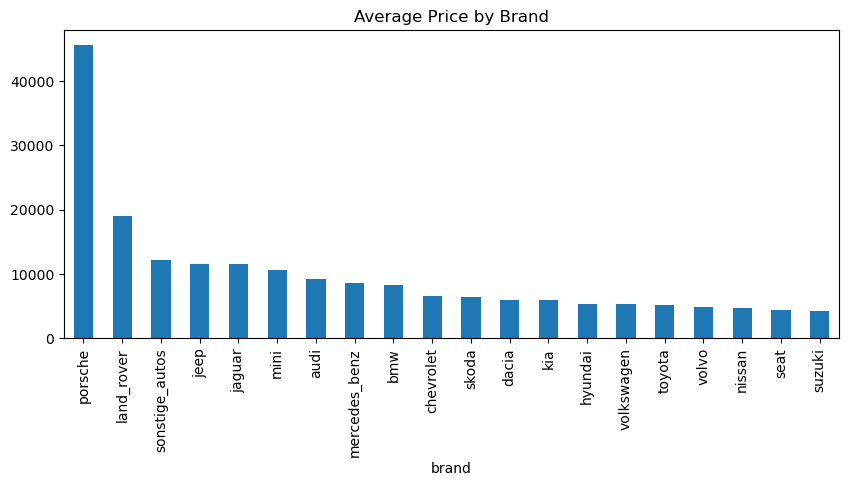

In [42]:
brand_price_mileage['price'].plot(kind='bar', figsize=(10, 4), title='Average Price by Brand')

<Axes: title={'center': 'Average Mileage by Brand'}, xlabel='brand'>

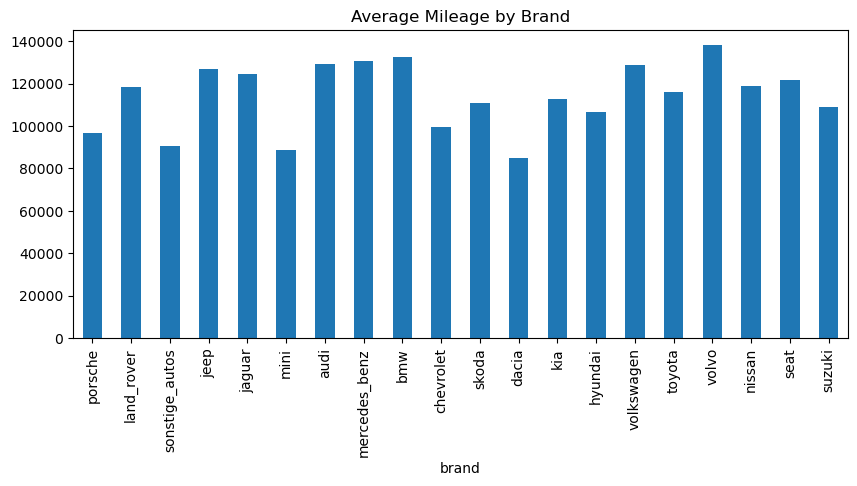

In [43]:
brand_price_mileage['odometer_km'].plot(kind='bar', figsize=(10, 4), title='Average Mileage by Brand')

<!-- # add by codex -->
The average mileage across the top 20 brands is relatively close compared with the much wider differences in average price. Most brands have average mileage in a fairly narrow range, roughly around 110,000 to 140,000 km, while average prices vary much more sharply, from about EUR 4,000 to over EUR 45,000.

There does not appear to be a strong relationship between average mileage and average brand price at the brand level. For example, Porsche has the highest average price, but it does not have unusually low average mileage. Premium brands such as Porsche, Audi, Mercedes-Benz, and BMW also remain relatively expensive even when their average mileage is similar to cheaper brands.

This suggests that brand reputation, market position, and model mix have a stronger influence on average price than mileage alone. Mileage may still matter within each brand: a lower-mileage BMW is likely to be more expensive than a higher-mileage BMW, but mileage does not fully explain the price differences between brands.

In [44]:
mileage_bins = [0, 30000, 60000, 90000, 120000, 150000]
mileage_labels = ['0-30k', '30k-60k', '60k-90k', '90k-120k', '120k-150k']

autos = autos.copy()

autos.loc[:, 'mileage_group'] = pd.cut(
    autos['odometer_km'],
    bins=mileage_bins,
    labels=mileage_labels,
    include_lowest=True
)

In [45]:
mileage_price = autos.groupby('mileage_group', observed=True)['price'].agg(
    avg_price='mean',
    median_price='median',
    cars_count='count'
)

mileage_price


,avg_price,median_price,cars_count
mileage_group,,,
0-30k,"14,846.43","9,500.00",2611
30k-60k,"13,626.70","10,000.00",2982
60k-90k,"9,469.10","6,999.00",4366
90k-120k,"8,017.49","5,499.00",2115
120k-150k,"4,062.30","2,350.00",36471


<Axes: xlabel='mileage_group'>

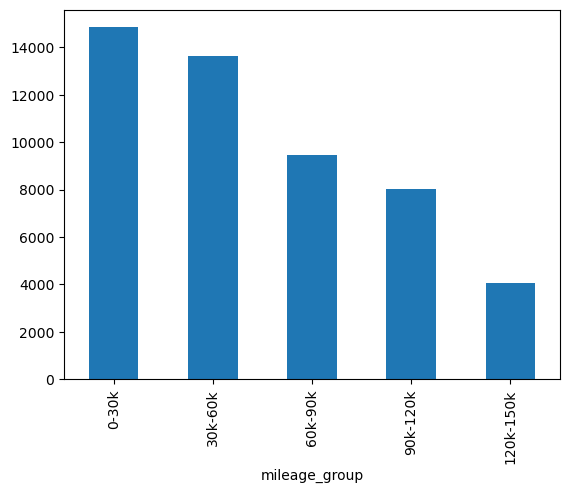

In [46]:
mileage_price['avg_price'].plot(kind='bar')

<!-- # add by codex -->
Average prices generally decrease as mileage increases. Cars in the lower-mileage groups tend to have higher average and median prices, while cars in the highest-mileage group are cheaper on average. This pattern makes sense because mileage is commonly used as a proxy for vehicle wear and remaining useful life.

The relationship is not perfectly smooth, though. Price is also affected by brand, model, registration year, fuel type, gearbox, vehicle condition, and whether the car has unrepaired damage.

### Find the most common brand/model combinations

In [47]:
brand_model_counts = (
    autos[['brand', 'model']]
    .dropna()
    .value_counts()
    .head(10)
    .rename_axis(['brand', 'model'])
    .reset_index(name='count')
)

brand_model_counts['proportion_pct'] = (
    brand_model_counts['count'] / len(autos) * 100
)
brand_model_counts['brand_model'] = (
    brand_model_counts['brand'] + ' ' + brand_model_counts['model']
)

brand_model_counts

,brand,model,count,proportion_pct,brand_model
0,volkswagen,golf,3898,8.03,volkswagen golf
1,bmw,3er,2686,5.53,bmw 3er
2,volkswagen,polo,1688,3.48,volkswagen polo
3,opel,corsa,1680,3.46,opel corsa
4,opel,astra,1410,2.90,opel astra
5,volkswagen,passat,1383,2.85,volkswagen passat
6,audi,a4,1256,2.59,audi a4
7,mercedes_benz,c_klasse,1161,2.39,mercedes_benz c_klasse
8,bmw,5er,1150,2.37,bmw 5er
9,mercedes_benz,e_klasse,977,2.01,mercedes_benz e_klasse


<Axes: title={'center': 'Most Common Brand/Model Combinations'}, ylabel='brand_model'>

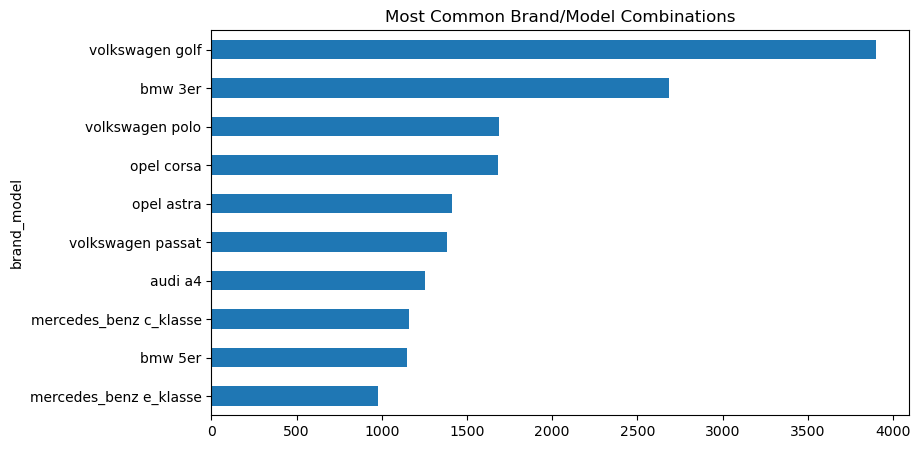

In [48]:
brand_model_counts.sort_values('count').plot(
    kind='barh',
    x='brand_model',
    y='count',
    legend=False,
    figsize=(9, 5),
    title='Most Common Brand/Model Combinations'
)

<!-- # add by codex -->
Among the ten most common brand/model combinations, Volkswagen appears most frequently. The Volkswagen Golf alone accounts for about 8.46% of the cleaned listings, followed by the BMW 3 Series at about 5.83% and the Volkswagen Polo at about 3.66%.

Volkswagen has three combinations in the top ten: Golf, Polo, and Passat. Together, these account for about 15.12% of the listings, which reinforces Volkswagen's strong presence in this used car market. BMW is also well represented through the 3 Series and 5 Series, which together account for about 8.32% of listings.

In [49]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48545 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date_crawled        48545 non-null  datetime64[ns]
 1   name                48545 non-null  object        
 2   price               48545 non-null  int64         
 3   ab_test             48545 non-null  object        
 4   vehicle_type        43979 non-null  object        
 5   registration_year   48545 non-null  int64         
 6   gearbox             46214 non-null  object        
 7   power_ps            48545 non-null  int64         
 8   model               46094 non-null  object        
 9   odometer_km         48545 non-null  int64         
 10  registration_month  48545 non-null  int64         
 11  fuel_type           44529 non-null  object        
 12  brand               48545 non-null  object        
 13  unrepaired_damage   39460 non-null  object        


### How much cheaper are cars with damage than their non-damaged counterparts?

<!-- # add by codex -->
The `unrepaired_damage` column is currently recorded in German: `nein` means `no`, and `ja` means `yes`. We will translate these values before comparing prices, so the results are easier to read.

In [50]:
# Before translation
autos['unrepaired_damage'].value_counts()

unrepaired_damage
nein    34771
ja       4689
Name: count, dtype: int64

In [51]:
# After translation
autos['unrepaired_damage'] = autos['unrepaired_damage'].replace({
    'nein': 'no',
    'ja': 'yes'
})

autos['unrepaired_damage'].value_counts(dropna=False)

unrepaired_damage
no     34771
NaN     9085
yes     4689
Name: count, dtype: int64

In [52]:
damage_price = autos.groupby('unrepaired_damage')['price'].agg(
    avg_price='mean',
    median_price='median',
    cars_count='count'
)

damage_price

,avg_price,median_price,cars_count
unrepaired_damage,,,
no,"7,086.10","4,000.00",34771
yes,"2,221.89","1,000.00",4689


In [53]:
no_damage_avg = damage_price.loc['no', 'avg_price']
damage_avg = damage_price.loc['yes', 'avg_price']

price_difference = no_damage_avg - damage_avg
discount_pct = price_difference / no_damage_avg * 100
price_ratio = no_damage_avg / damage_avg

print(f'Average price difference: EUR {price_difference:,.0f}')
print(f'Damaged cars are {discount_pct:.1f}% cheaper on average.')
print(f'Non-damaged cars are {price_ratio:.1f}x as expensive as damaged cars.')

Average price difference: EUR 4,864
Damaged cars are 68.6% cheaper on average.
Non-damaged cars are 3.2x as expensive as damaged cars.


<Axes: title={'center': 'Average and Median Price by Damage Status'}, xlabel='unrepaired_damage'>

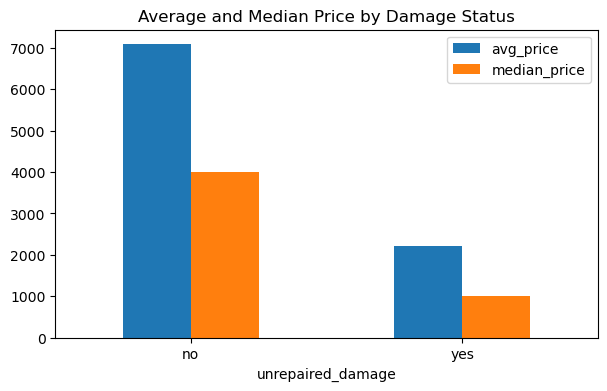

In [54]:
damage_price[['avg_price', 'median_price']].plot(
    kind='bar',
    figsize=(7, 4),
    title='Average and Median Price by Damage Status',
    rot=0
)

<!-- # add by codex -->
Cars with unrepaired damage are much cheaper than cars without unrepaired damage. The average price for cars without unrepaired damage is about EUR 7,086, while the average price for cars with unrepaired damage is about EUR 2,222.

This means damaged cars are about 69% cheaper than non-damaged cars, or roughly 3.2 times cheaper. This is a strong difference, which suggests that unrepaired damage has a major negative relationship with listed price.